# 2 - Visualization
Overlaying student GPS submissions on top of the physical amphitheater footprint polygons.

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import os

## 1. Load Student GPS Data
We load the dataset and reverse the row order (newest-first export).

In [6]:
csv_path = r'C:\Users\ASUS\Desktop\3y\S2\machine learning\Project\Local\Data\ensia_gps_data .csv'
df = pd.read_csv(csv_path)

# Reverse order (export is newest-first)
df = df.iloc[::-1].reset_index(drop=True)

print(f"Loaded {len(df)} submissions.")
df[['Amphi', 'Lat_Mean', 'Lng_Mean', 'IsOutside']].head()

Loaded 41 submissions.


,Amphi,Lat_Mean,Lng_Mean,IsOutside
0,Amphi 3,36.687824,2.867150,False
1,lab 8,36.688127,2.867512,True
2,School entry,36.688729,2.865596,True
3,Amphi 4,36.688630,2.866750,False
4,room,36.688630,2.866750,True


## 2. Amphitheater Landmarks (Polygons)
Physical boundaries for the 4 amphitheater spaces.

In [7]:
amphi_corners = {
    "Amphi 1/5": [
        (36.6882320, 2.8666535),  # top-left
        (36.6882443, 2.8668060),  # top-right
        (36.6880865, 2.8668389),  # bottom-right
        (36.6880720, 2.8666538),  # bottom-left
    ],
    "Amphi 2/6": [
        (36.6882129, 2.8663997),  # top-left
        (36.6882193, 2.8665428),  # top-right
        (36.6880268, 2.8665894),  # bottom-right
        (36.6880123, 2.8663926),  # bottom-left
    ],
    "Amphi 3/7": [
        (36.6881935, 2.8661324),  # top-left
        (36.6881954, 2.8662759),  # top-right
        (36.6880368, 2.8663122),  # bottom-right
        (36.6880252, 2.8661318),  # bottom-left
    ],
    "Amphi 4/8": [
        (36.6881693, 2.8658652),  # top-left
        (36.6881817, 2.8660131),  # top-right
        (36.6880179, 2.8660490),  # bottom-right
        (36.6880075, 2.8658649),  # bottom-left
    ],
}

## 3. Analysis Plot
Visualizing submissions on top of physical basins to check for drift and accuracy.

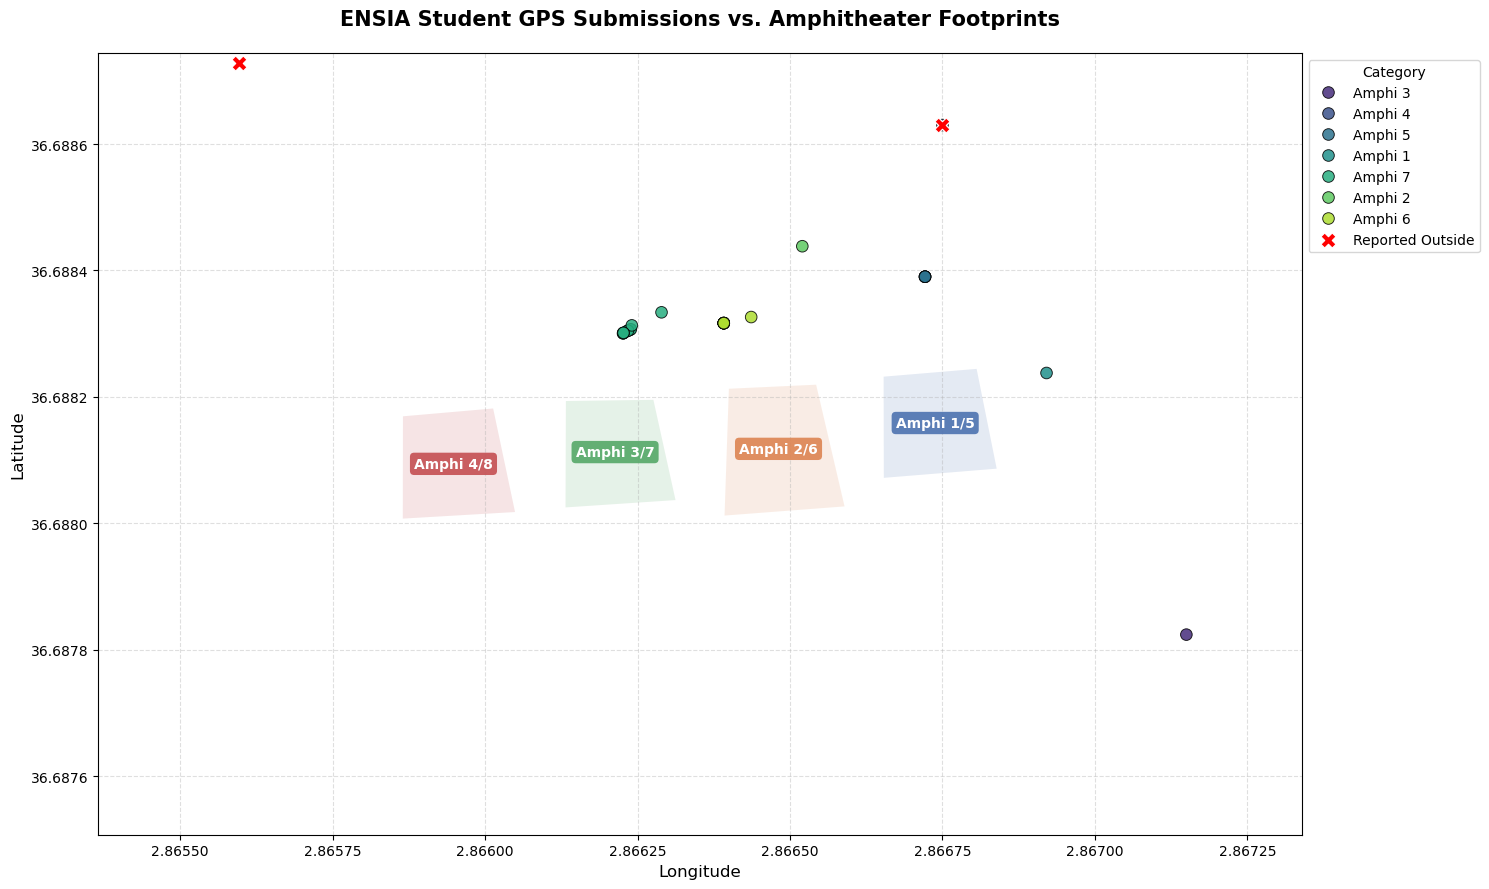

In [8]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
amphi_names = list(amphi_corners.keys())

fig, ax = plt.subplots(figsize=(15, 9))

# 1. Plot Polygons (Amphi Areas)
patches = []
for (name, corners), color in zip(amphi_corners.items(), colors):
    # Convert (lat, lon) -> (lon, lat) for (x, y) coordinates
    xy = np.array([(lon, lat) for lat, lon in corners])
    poly = Polygon(xy, closed=True)
    patches.append(poly)

    # Label the amphi at center
    cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
    ax.text(cx, cy, name, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none', alpha=0.9))

collection = PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1)
ax.add_collection(collection)

# 2. Scatter Student Submissions
# We differentiate indoor submissions by claimed Amphi and mark 'IsOutside' separately
df_indoor = df[~df['IsOutside']]
df_outdoor = df[df['IsOutside']]

scatter = sns.scatterplot(
    data=df_indoor, x='Lng_Mean', y='Lat_Mean', hue='Amphi', 
    marker='o', s=70, alpha=0.85, edgecolor='black', palette='viridis', ax=ax, zorder=3
)

sns.scatterplot(
    data=df_outdoor, x='Lng_Mean', y='Lat_Mean', 
    marker='X', s=120, color='red', label='Reported Outside', ax=ax, zorder=4
)

# Axis formatting
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('ENSIA Student GPS Submissions vs. Amphitheater Footprints', fontsize=15, fontweight='bold', pad=20)
ax.ticklabel_format(useOffset=False)
ax.grid(True, linestyle='--', alpha=0.4)

# Legend
ax.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Set limits based on polygons with small buffer
all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
all_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(all_lons) - 0.0005, max(all_lons) + 0.0005)
ax.set_ylim(min(all_lats) - 0.0005, max(all_lats) + 0.0005)

plt.tight_layout()
plt.savefig('ensia_gps_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
csv_path = r'C:\Users\ASUS\Desktop\3y\S2\machine learning\Project\Local\Data\ensia_gps_data .csv'
df_merged = pd.read_csv(csv_path)

# Reverse order (export is newest-first)
df_merged = df_merged.iloc[::-1].reset_index(drop=True)

print(f"Loaded {len(df_merged)} submissions.")
df_merged[['Amphi', 'Lat_Mean', 'Lng_Mean', 'IsOutside']].head()